# Urban Air Quality Prediction — CNN-LSTM Implementation
**MSc Data Science Dissertation | University of Roehampton**

**Student:** Shifa Ali Asif Sayed | **ID:** A00072650 | MSc Data Science


---
## Section 0 — Setup and Dependencies

In [1]:
!pip install -q cdsapi xarray netCDF4 h5py h5netcdf \
    imbalanced-learn xgboost shap folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.2 MB/s eta 0:00:00


In [2]:
import os, json, random, warnings, zipfile, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
import xarray as xr

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, f1_score,
    mean_squared_error, r2_score, mean_absolute_error,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device     :', DEVICE)
print('PyTorch    :', torch.__version__)
if torch.cuda.is_available():
    print('GPU        :', torch.cuda.get_device_name(0))

SEQ_LEN    = 24
BATCH_SIZE = 64
UK_CITIES  = ['London', 'Manchester', 'Birmingham', 'Leeds', 'Bristol']

AQI_CLASSES = ['Good', 'Moderate', 'Unhealthy_Sensitive', 'Unhealthy', 'Very_Unhealthy']
AQI_COLORS  = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97']

for d in ['data/raw/openaq', 'data/raw/era5', 'data/processed',
          'models', 'outputs/figures', 'outputs/results']:
    Path(d).mkdir(parents=True, exist_ok=True)

print('Directories ready')

Device     : cuda
PyTorch    : 2.11.0+cu128
GPU        : Tesla T4
Directories ready


---
## Section 1 — Data Acquisition

### 1.1 OpenAQ API Key

In [3]:
try:
    from google.colab import userdata
    OPENAQ_API_KEY = userdata.get('OPENAQ_API_KEY')
    print('API key loaded from Colab Secrets')
except Exception:
    OPENAQ_API_KEY = os.getenv('OPENAQ_API_KEY', 'YOUR-OPENAQ-API-KEY')
    print('API key loaded from environment')

OPENAQ_HEADERS = {'X-API-Key': OPENAQ_API_KEY}
OPENAQ_BASE    = 'https://api.openaq.org/v3'

# Quick sanity check — confirms the key actually authenticates before proceeding
test_resp = requests.get(f'{OPENAQ_BASE}/locations', params={'limit': 1}, headers=OPENAQ_HEADERS, timeout=10)
print('API key test status:', test_resp.status_code, '-- 200 means working')

API key loaded from Colab Secrets
API key test status: 200 -- 200 means working


### 1.2 OpenAQ — Ground PM2.5 Sensors (Fixed Method)

**Root cause found during debugging:** the OpenAQ v3 `city=` query parameter does not reliably filter
results — it silently returns stations from other countries entirely. The fix verifies each result's
`country.code == 'GB'` explicitly and uses a geographic bounding box instead of the unreliable city filter.

In [4]:
def safe_dt(d: dict, key: str):
    """Safely extract a datetime.utc value, handling None sub-dicts from the API."""
    sub = d.get(key)
    return sub.get('utc') if sub else None


def get_uk_locations_by_bbox(city_name: str, bbox: tuple, limit: int = 100) -> pd.DataFrame:
    """
    Fetch PM2.5 sensors within a bounding box, verifying country=GB explicitly.
    bbox format: (west, south, east, north)
    """
    resp = requests.get(
        f'{OPENAQ_BASE}/locations',
        params={
            'bbox': ','.join(map(str, bbox)),
            'parameters_id': 2,   # 2 = pm25 in OpenAQ v3 parameter IDs
            'limit': limit
        },
        headers=OPENAQ_HEADERS, timeout=15
    )
    resp.raise_for_status()
    records = []
    for loc in resp.json().get('results', []):
        coords  = loc.get('coordinates', {})
        country = loc.get('country', {})
        if not (coords.get('latitude') and coords.get('longitude')):
            continue
        if country.get('code') != 'GB':   # verify genuine UK station
            continue
        sensors  = loc.get('sensors', [])
        pm25_ids = [s['id'] for s in sensors if s.get('parameter', {}).get('name') == 'pm25']
        for sid in pm25_ids:
            records.append({
                'location_id': loc['id'], 'sensor_id': sid,
                'name': loc.get('name', 'Unknown'),
                'city_label': city_name,
                'lat': coords['latitude'], 'lon': coords['longitude'],
                'first': safe_dt(loc, 'datetimeFirst'),
                'last':  safe_dt(loc, 'datetimeLast'),
            })
    return pd.DataFrame(records)


# Bounding boxes (west, south, east, north) for each UK city
CITY_BBOXES = {
    'London':     (-0.51, 51.28, 0.33, 51.69),
    'Manchester': (-2.42, 53.35, -2.05, 53.56),
    'Birmingham': (-2.05, 52.38, -1.73, 52.60),
    'Leeds':      (-1.75, 53.72, -1.40, 53.88),
    'Bristol':    (-2.72, 51.40, -2.48, 51.53),
}

loc_frames = []
for city, bbox in CITY_BBOXES.items():
    df = get_uk_locations_by_bbox(city, bbox)
    if not df.empty:
        loc_frames.append(df)
        print(f'{city}: {len(df)} genuine UK sensors found')
    else:
        print(f'{city}: 0 sensors in bounding box')

locations_df = pd.concat(loc_frames, ignore_index=True) if loc_frames else pd.DataFrame()
print(f'\nTotal genuine UK sensors: {len(locations_df)}')
display(locations_df.head(8))

London: 100 genuine UK sensors found
Manchester: 18 genuine UK sensors found
Birmingham: 25 genuine UK sensors found
Leeds: 3 genuine UK sensors found
Bristol: 4 genuine UK sensors found

Total genuine UK sensors: 150


,location_id,sensor_id,name,city_label,lat,lon,first,last
0,60,206,Haringey Roadside - UKA00260,London,51.599300,-0.068218,2016-01-30T01:00:00Z,2026-08-04T15:00:00Z
1,137,211,Harrow - Stanmore,London,51.617327,-0.298775,2016-01-30T01:00:00Z,2023-08-14T09:00:00Z
2,141,261,London Harlington - UKA00472,London,51.488790,-0.441614,2016-01-30T01:00:00Z,2026-05-26T13:00:00Z
3,146,1304692,Southwark - A2 Old Kent Road,London,51.480499,-0.059553,2016-01-30T01:00:00Z,2026-08-04T15:00:00Z
4,147,228,Greenwich - Eltham,London,51.452580,0.070766,2016-02-01T11:00:00Z,2024-05-30T08:00:00Z
5,148,232,London Bloomsbury - UKA00211,London,51.522290,-0.125889,2016-01-30T01:00:00Z,2026-05-28T15:00:00Z
6,150,12626392,London Haringey Priory Park South - UKA00568,London,51.584128,-0.125254,2016-01-30T01:00:00Z,2026-08-04T15:00:00Z
7,151,12915957,Tower Hamlets - Mile End Road,London,51.522529,-0.042155,2016-02-05T17:00:00Z,2026-08-04T15:00:00Z


In [5]:
# Filter to sensors that actually cover the full 2017 study period
locations_df['first_dt'] = pd.to_datetime(locations_df['first'])
locations_df['last_dt']  = pd.to_datetime(locations_df['last'])

covers_2017 = locations_df[
    (locations_df['first_dt'] <= '2017-01-01') &
    (locations_df['last_dt']  >= '2017-12-31')
].copy()

print(f'Sensors covering full 2017: {len(covers_2017)} out of {len(locations_df)}')
print(covers_2017.groupby('city_label').size())

Sensors covering full 2017: 24 out of 150
city_label
Birmingham     3
Leeds          2
London        16
Manchester     3
dtype: int64


### 1.3 Fetch Real Measurements (with retry, backoff, and time budget)

In [6]:
def get_measurements_by_sensor(sensor_id: int, date_from: str, date_to: str,
                                max_retries: int = 3) -> pd.DataFrame:
    """
    Fetch measurements via the v3 sensor endpoint with pagination and
    retry-with-backoff on timeout, so a single slow sensor cannot silently
    drop data or stall the whole fetch loop.
    """
    all_records, page = [], 1
    while True:
        resp = None
        for attempt in range(max_retries):
            try:
                resp = requests.get(
                    f'{OPENAQ_BASE}/sensors/{sensor_id}/measurements',
                    params={'date_from': date_from, 'date_to': date_to, 'limit': 1000, 'page': page},
                    headers=OPENAQ_HEADERS, timeout=30
                )
                resp.raise_for_status()
                break
            except Exception:
                if attempt < max_retries - 1:
                    time.sleep(2 * (attempt + 1))
                    continue
                return pd.DataFrame(all_records)   # give up on this sensor, keep what we have

        results = resp.json().get('results', [])
        if not results:
            break
        for r in results:
            ts = (r.get('period', {}).get('datetimeTo', {}).get('utc')
                  or r.get('date', {}).get('utc', ''))
            all_records.append({'datetime': ts, 'pm25': r.get('value'), 'sensor_id': sensor_id})
        if len(results) < 1000:
            break
        page += 1
        time.sleep(0.3)   # be polite to the API between pages
    return pd.DataFrame(all_records)

print('Fetch function ready (retry + backoff enabled)')

Fetch function ready (retry + backoff enabled)


In [7]:
# Fetch real 2017 measurements, cached to avoid repeating an expensive run
CACHE = Path('data/processed/openaq_real_2017.csv')
TIME_BUDGET_SECONDS = 900   # 15-minute hard cap so this cannot hang indefinitely

if CACHE.exists() and CACHE.stat().st_size > 100:
    print('Loading cached real measurements...')
    openaq_raw = pd.read_csv(CACHE)
    print(f'Loaded {len(openaq_raw):,} real records')
else:
    print('Fetching real 2017 measurements from confirmed UK sensors...')
    start = time.time()
    meas_frames = []
    for i, row in covers_2017.iterrows():
        if time.time() - start > TIME_BUDGET_SECONDS:
            print('Time budget reached — stopping fetch, proceeding with data collected so far.')
            break
        df = get_measurements_by_sensor(int(row['sensor_id']), '2017-01-01', '2017-12-31')
        if not df.empty:
            df['lat']  = row['lat']
            df['lon']  = row['lon']
            df['city'] = row['city_label']
            meas_frames.append(df)
            print(f"  {row['name']}: {len(df):,} records")

    openaq_raw = pd.concat(meas_frames, ignore_index=True) if meas_frames else pd.DataFrame()
    if not openaq_raw.empty:
        openaq_raw.to_csv(CACHE, index=False)
    print(f'\nTotal real 2017 records: {len(openaq_raw):,}')
    print(f'Elapsed: {time.time()-start:.0f}s')

print(f'Shape: {openaq_raw.shape}')
if not openaq_raw.empty:
    print(f'Sensors: {openaq_raw["sensor_id"].nunique()}  |  Cities: {openaq_raw["city"].nunique()}')
    display(openaq_raw.head())

Fetching real 2017 measurements from confirmed UK sensors...
  Haringey Roadside - UKA00260: 247 records
  Harrow - Stanmore: 8,358 records
  London Harlington - UKA00472: 14,000 records
  Southwark - A2 Old Kent Road: 17,000 records
  Greenwich - Eltham: 15,000 records
  London Bloomsbury - UKA00211: 17,000 records
  London Haringey Priory Park South - UKA00568: 7,768 records
  Tower Hamlets - Mile End Road: 10,269 records
  Camden Kerbside - UKA00259: 17,000 records
  London Hillingdon - UKA00266: 17,000 records
  London Marylebone Road - UKA00315: 4,000 records
  Kensington and Chelsea - North Ken: 11,000 records
  Bexley - Slade Green: 11,000 records
  London Teddington Bushy Park - UKA00572: 17,000 records
Time budget reached — stopping fetch, proceeding with data collected so far.

Total real 2017 records: 166,642
Elapsed: 979s
Shape: (166642, 6)
Sensors: 14  |  Cities: 1


,datetime,pm25,sensor_id,lat,lon,city
0,2016-01-30T01:00:00Z,7.0,206,51.5993,-0.068218,London
1,2016-01-30T02:00:00Z,7.0,206,51.5993,-0.068218,London
2,2016-01-30T03:00:00Z,7.0,206,51.5993,-0.068218,London
3,2016-01-30T04:00:00Z,7.0,206,51.5993,-0.068218,London
4,2016-01-30T05:00:00Z,7.0,206,51.5993,-0.068218,London


### 1.4 Synthetic Fallback



In [8]:
if openaq_raw.empty:
    print('No real data available — generating synthetic fallback for pipeline continuity...')
    rng   = np.random.default_rng(SEED)
    dates = pd.date_range('2017-01-01', '2017-12-31', freq='h')

    synth_frames = []
    for city, (base_lat, base_lon, base_pm25) in zip(
        UK_CITIES,
        [(51.5, -0.1, 18), (53.5, -2.2, 25), (52.5, -1.9, 32), (53.8, -1.5, 12), (51.5, -2.6, 45)]
    ):
        doy      = dates.dayofyear
        seasonal = 20 * np.cos(2 * np.pi * (doy - 15) / 365)
        diurnal  = 8  * np.sin(2 * np.pi * dates.hour / 24)
        noise    = rng.normal(0, 10, len(dates))
        spikes   = rng.exponential(35, len(dates)) * (rng.random(len(dates)) < 0.06)
        pm25_vals = np.clip(base_pm25 + seasonal + diurnal + noise + spikes, 1, 250)
        synth_frames.append(pd.DataFrame({
            'datetime': dates.strftime('%Y-%m-%dT%H:%M:%SZ'),
            'pm25': pm25_vals, 'lat': base_lat, 'lon': base_lon, 'city': city,
        }))
    openaq_raw = pd.concat(synth_frames, ignore_index=True)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    openaq_raw.to_csv(CACHE, index=False)
    print(f'Synthetic fallback: {len(openaq_raw):,} records')
else:
    print('Real data already loaded — synthetic fallback skipped.')

Real data already loaded — synthetic fallback skipped.


### 1.5 ERA5 Meteorological Data

In [9]:
try:
    from google.colab import userdata
    CDS_TOKEN = userdata.get('CDS_TOKEN')
    print('CDS token loaded from Colab Secrets')
except Exception:
    CDS_TOKEN = 'YOUR-PERSONAL-ACCESS-TOKEN'

with open('/root/.cdsapirc', 'w') as f:
    f.write(f"url: https://cds.climate.copernicus.eu/api\nkey: {CDS_TOKEN}\n")
print('CDS config written')

CDS token loaded from Colab Secrets
CDS config written


In [10]:
import cdsapi

ERA5_DIR  = Path('data/raw/era5')
ERA5_FILE = ERA5_DIR / 'era5_uk_2017.nc'

VARIABLES = [
    '10m_u_component_of_wind', '10m_v_component_of_wind',
    '2m_temperature', 'surface_pressure',
    'total_precipitation', 'boundary_layer_height',
    '2m_dewpoint_temperature',
]

if not ERA5_FILE.exists():
    c = cdsapi.Client()
    monthly_files = []
    for month in range(1, 13):
        out_file = ERA5_DIR / f'era5_uk_2017_{month:02d}.nc'
        monthly_files.append(out_file)
        if out_file.exists():
            print(f'Month {month:02d}: cached')
            continue
        print(f'Downloading month {month:02d}...')
        c.retrieve('reanalysis-era5-single-levels', {
            'product_type': ['reanalysis'], 'variable': VARIABLES,
            'year': ['2017'], 'month': [f'{month:02d}'],
            'day': [f'{d:02d}' for d in range(1, 32)],
            'time': ['00:00', '06:00', '12:00', '18:00'],
            'area': [61, -8, 49.5, 2], 'data_format': 'netcdf',
        }, str(out_file))
        print(f'Month {month:02d} saved')
        time.sleep(2)

    unzipped = []
    for f in monthly_files:
        if not f.exists():
            continue
        with open(f, 'rb') as fh:
            magic = fh.read(4)
        if magic[:2] == b'PK':
            extract_dir = ERA5_DIR / f.stem
            extract_dir.mkdir(exist_ok=True)
            with zipfile.ZipFile(f, 'r') as zf:
                zf.extractall(extract_dir)
                for name in zf.namelist():
                    unzipped.append(extract_dir / name)
        else:
            unzipped.append(f)

    print('Merging monthly files...')
    ds = xr.open_mfdataset([str(f) for f in unzipped if f.exists()],
                            combine='by_coords', engine='netcdf4')
    ds.to_netcdf(str(ERA5_FILE))
    ds.close()
    print(f'ERA5 saved: {ERA5_FILE}')
else:
    print(f'ERA5 cache found: {ERA5_FILE}')

2026-08-04 17:01:39,661 INFO Request ID is 0a83acdd-c7dc-44dd-8e75-ffdfc626e954
INFO:ecmwf.datastores.legacy_client:Request ID is 0a83acdd-c7dc-44dd-8e75-ffdfc626e954
2026-08-04 17:01:39,898 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-08-04 17:02:13,418 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


101b8458300030fa192201cc824daa48.zip:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

Month 01 saved


2026-08-04 17:02:18,949 INFO Request ID is ba1d5d40-8aec-4d0e-8e87-057d4f4c53e0
INFO:ecmwf.datastores.legacy_client:Request ID is ba1d5d40-8aec-4d0e-8e87-057d4f4c53e0
2026-08-04 17:02:19,134 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-08-04 17:03:10,516 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


fa2749aaecfde38adebef6dd488b0abf.zip:   0%|          | 0.00/2.65M [00:00<?, ?B/s]

...

44242d8b41dfc7e1231bc3918c411aa.zip:   0%|          | 0.00/2.86M [00:00<?, ?B/s]

Month 11 saved


2026-08-04 17:10:49,557 INFO Request ID is f903ec2e-6776-4373-8dd1-8067fbf9d1d8
INFO:ecmwf.datastores.legacy_client:Request ID is f903ec2e-6776-4373-8dd1-8067fbf9d1d8
2026-08-04 17:10:49,760 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-08-04 17:11:25,481 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-08-04 17:11:42,766 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


7f2657512d878f7487b373db42dee4a4.zip:   0%|          | 0.00/2.96M [00:00<?, ?B/s]

Month 12 saved
Merging monthly files...
ERA5 saved: data/raw/era5/era5_uk_2017.nc


In [11]:
def extract_era5_at_points(nc_file: str, lats: list, lons: list) -> pd.DataFrame:
    """
    Extract ERA5 variables at sensor locations, aggregate to daily means.
    Handles 'valid_time' (new CDS API 2024+) and 'time' (old API) automatically.
    Returns empty DataFrame gracefully if extraction fails.
    """
    try:
        ds       = xr.open_dataset(nc_file, engine='netcdf4')
        time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
        print(f'ERA5 dims: {dict(ds.dims)}  vars: {list(ds.data_vars)}  time_dim: {time_dim}')
        records = []
        for lat, lon in zip(lats, lons):
            try:
                pt = ds.sel(latitude=lat, longitude=lon, method='nearest')
                df = pt.to_dataframe().reset_index()
                df = df.loc[:, ~df.columns.duplicated()]
                time_col = next((c for c in [time_dim, 'valid_time', 'time'] if c in df.columns), None)
                if time_col is None:
                    df = df.reset_index()
                    time_col = next((c for c in [time_dim, 'valid_time', 'time'] if c in df.columns), None)
                if time_col is None:
                    continue
                df['lat']  = lat
                df['lon']  = lon
                df['date'] = pd.to_datetime(df[time_col]).dt.normalize()
                if 'u10' in df.columns and 'v10' in df.columns:
                    df['wind_speed'] = np.sqrt(df['u10']**2 + df['v10']**2)
                if 't2m' in df.columns and 'd2m' in df.columns:
                    df['rh'] = 100 * (
                        np.exp((17.625*(df['d2m']-273.15))/(243.04+df['d2m']-273.15)) /
                        np.exp((17.625*(df['t2m']-273.15))/(243.04+df['t2m']-273.15))
                    )
                agg = {k:'mean' for k in ['t2m','sp','wind_speed','rh','blh'] if k in df.columns}
                if 'tp' in df.columns: agg['tp'] = 'sum'
                if agg:
                    records.append(df.groupby(['date','lat','lon']).agg(agg).reset_index())
            except Exception as e:
                print(f'  Warning at location: {e}')
        ds.close()
        if not records:
            print('ERA5 extraction: no records — ERA5 features skipped')
            return pd.DataFrame()
        result = pd.concat(records, ignore_index=True)
        print(f'ERA5 extraction complete: {result.shape}')
        return result
    except Exception as e:
        print(f'ERA5 extraction error: {e}')
        return pd.DataFrame()

print('ERA5 extraction function defined')

ERA5 extraction function defined


---
## Section 2 — Preprocessing

In [12]:
def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclical temporal encodings for day-of-year, month, and weekday."""
    df = df.copy()
    df['date']        = pd.to_datetime(df['date'])
    df['doy']         = df['date'].dt.dayofyear
    df['month']       = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    df['doy_sin']     = np.sin(2 * np.pi * df['doy']   / 365)
    df['doy_cos']     = np.cos(2 * np.pi * df['doy']   / 365)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    return df


def pm25_to_aqi_band(pm25: float) -> str:
    """Convert PM2.5 µg/m3 to US EPA AQI band label."""
    if   pm25 <= 12.0:  return 'Good'
    elif pm25 <= 35.4:  return 'Moderate'
    elif pm25 <= 55.4:  return 'Unhealthy_Sensitive'
    elif pm25 <= 150.4: return 'Unhealthy'
    else:               return 'Very_Unhealthy'


def build_sequences(X: np.ndarray, y: np.ndarray, seq_len: int = 24) -> tuple:
    """Build overlapping sliding-window sequences for CNN/LSTM input."""
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs, dtype=np.float32), np.array(ys)

print('Preprocessing functions defined')

Preprocessing functions defined


In [13]:
# Build daily dataset inline — avoids any cache corruption issues
df = openaq_raw.copy()

# Parse datetime robustly — replace Z suffix for pandas compatibility
df['datetime'] = pd.to_datetime(
    df['datetime'].astype(str).str.replace('Z', '+00:00', regex=False),
    utc=True, errors='coerce'
)
df = df.dropna(subset=['datetime'])
df = df[(df['pm25'] >= 0) & (df['pm25'] <= 500)]
df['date'] = df['datetime'].dt.normalize().dt.tz_localize(None)

# Round coordinates so hourly readings from same location aggregate correctly
df['lat'] = df['lat'].round(2)
df['lon'] = df['lon'].round(2)

daily_df = df.groupby(['date','lat','lon','city']).agg(
    pm25     = ('pm25','mean'),
    pm25_max = ('pm25','max'),
    pm25_std = ('pm25','std'),
    n_hours  = ('pm25','count'),
).reset_index()

print(f'Before n_hours filter: {len(daily_df)} rows')
print(f'n_hours range: {daily_df["n_hours"].min()} to {daily_df["n_hours"].max()}')

daily_df = daily_df[daily_df['n_hours'] >= 12].copy()
print(f'After n_hours >= 12 filter: {len(daily_df)} rows')

daily_df = add_temporal_features(daily_df)
daily_df['aqi_band'] = daily_df['pm25'].apply(pm25_to_aqi_band)

# Merge ERA5 if available
if ERA5_FILE.exists():
    unique_locs = daily_df[['lat','lon']].drop_duplicates()
    era5_data   = extract_era5_at_points(
        str(ERA5_FILE), unique_locs['lat'].tolist(), unique_locs['lon'].tolist()
    )
    if not era5_data.empty:
        era5_data['date'] = pd.to_datetime(era5_data['date'])
        daily_df['date']  = pd.to_datetime(daily_df['date'])
        daily_df = daily_df.merge(era5_data, on=['date','lat','lon'], how='left')
        print('ERA5 features merged')

daily_df.to_csv('data/processed/daily_pm25_full_history.csv', index=False)  # saved before 2017 restriction — contains all years fetched

print(f'Final daily_df: {daily_df.shape}')
print()
print('AQI band distribution:')
print(daily_df['aqi_band'].value_counts().to_string())
display(daily_df.head())

Before n_hours filter: 7960 rows
n_hours range: 1 to 24
After n_hours >= 12 filter: 7452 rows
ERA5 dims: {'valid_time': 1460, 'latitude': 47, 'longitude': 41}  vars: ['u10', 'v10', 't2m', 'sp', 'blh', 'd2m', 'tp']  time_dim: valid_time
ERA5 extraction complete: (5110, 9)
ERA5 features merged
Final daily_df: (7452, 23)

AQI band distribution:
aqi_band
Good                   5226
Moderate               2077
Unhealthy_Sensitive     126
Unhealthy                23


,date,lat,lon,city,pm25,pm25_max,pm25_std,n_hours,doy,month,...,doy_cos,month_sin,month_cos,aqi_band,t2m,sp,wind_speed,rh,blh,tp
0,2016-01-30,51.43,-0.35,London,1.260870,2.0,0.448978,23,30,1,...,0.869589,0.5,0.866025,Good,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-30,51.49,-0.44,London,8.105263,9.0,0.315302,19,30,1,...,0.869589,0.5,0.866025,Good,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-30,51.52,-0.13,London,3.347826,5.0,0.647281,23,30,1,...,0.869589,0.5,0.866025,Good,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-30,51.54,-0.18,London,5.304348,7.0,0.634950,23,30,1,...,0.869589,0.5,0.866025,Good,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-30,51.60,-0.07,London,6.478261,7.0,0.510754,23,30,1,...,0.869589,0.5,0.866025,Good,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Fix: OpenAQ ignored date_from/date_to and returned each sensor's full
# historical record instead of just one target year. Diagnostics showed the original target year has almost
# no coverage, but 2017 has strong coverage (31,731 raw records) and ERA5
# has now been re-downloaded for 2017 to match. Restrict daily_df to the
# genuine 2017 study period so the chronological split and ERA5 features
# are meaningful.
daily_df['date'] = pd.to_datetime(daily_df['date'])
daily_df = daily_df[(daily_df['date'] >= '2017-01-01') & (daily_df['date'] <= '2017-12-31')].copy()

print(f'Restricted to 2017: {len(daily_df)} rows')
if len(daily_df) > 0:
    print(f'Date range: {daily_df["date"].min().date()} to {daily_df["date"].max().date()}')
    print(f'ERA5 non-null rows: {daily_df["t2m"].notna().sum()} / {len(daily_df)}')
    print()
    print('AQI band distribution (2017 only):')
    print(daily_df['aqi_band'].value_counts().to_string())
else:
    print('WARNING: still 0 rows — check that ERA5 was re-downloaded for 2017 and openaq_raw has 2017 coverage.')


Restricted to 2017: 1881 rows
Date range: 2017-01-01 to 2017-12-31
ERA5 non-null rows: 1881 / 1881

AQI band distribution (2017 only):
aqi_band
Good                   1166
Moderate                646
Unhealthy_Sensitive      60
Unhealthy                 9


In [15]:
# Time-based train/test split — chronological, no random shuffle
daily_df['date'] = pd.to_datetime(daily_df['date'])
train_df = daily_df[daily_df['date'] < '2017-10-01'].sort_values(['city','date']).reset_index(drop=True)
test_df  = daily_df[daily_df['date'] >= '2017-10-01'].sort_values(['city','date']).reset_index(drop=True)

print(f'Train: {len(train_df):,} rows  ({train_df["date"].min().date()} to {train_df["date"].max().date()})')
print(f'Test:  {len(test_df):,} rows  ({test_df["date"].min().date()} to {test_df["date"].max().date()})')

TEMPORAL_FEATS  = ['doy_sin','doy_cos','month_sin','month_cos','is_weekend','day_of_week']
ERA5_FEATS      = ['t2m','sp','wind_speed','rh','blh','tp']
SATELLITE_FEATS = ['aod_550nm']

PHASE1_FEATS = TEMPORAL_FEATS + [f for f in ERA5_FEATS      if f in daily_df.columns]
PHASE2_FEATS = PHASE1_FEATS   + [f for f in SATELLITE_FEATS if f in daily_df.columns]

print(f'Phase 1 features ({len(PHASE1_FEATS)}): {PHASE1_FEATS}')

scaler   = MinMaxScaler()
X_tr_p1  = scaler.fit_transform(train_df[PHASE1_FEATS].fillna(0).values)
X_te_p1  = scaler.transform(test_df[PHASE1_FEATS].fillna(0).values)
y_tr_reg = train_df['pm25'].values
y_te_reg = test_df['pm25'].values

X_seq_tr, y_seq_tr = build_sequences(X_tr_p1, y_tr_reg, SEQ_LEN)
X_seq_te, y_seq_te = build_sequences(X_te_p1, y_te_reg, SEQ_LEN)

n_features = X_seq_tr.shape[2]
print(f'Train sequences: {X_seq_tr.shape}')
print(f'Test sequences:  {X_seq_te.shape}')
print(f'n_features: {n_features}')

Train: 1,488 rows  (2017-01-01 to 2017-09-30)
Test:  393 rows  (2017-10-01 to 2017-12-31)
Phase 1 features (12): ['doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'is_weekend', 'day_of_week', 't2m', 'sp', 'wind_speed', 'rh', 'blh', 'tp']
Train sequences: (1464, 24, 12)
Test sequences:  (369, 24, 12)
n_features: 12


---
## Section 3 — Exploratory Data Analysis

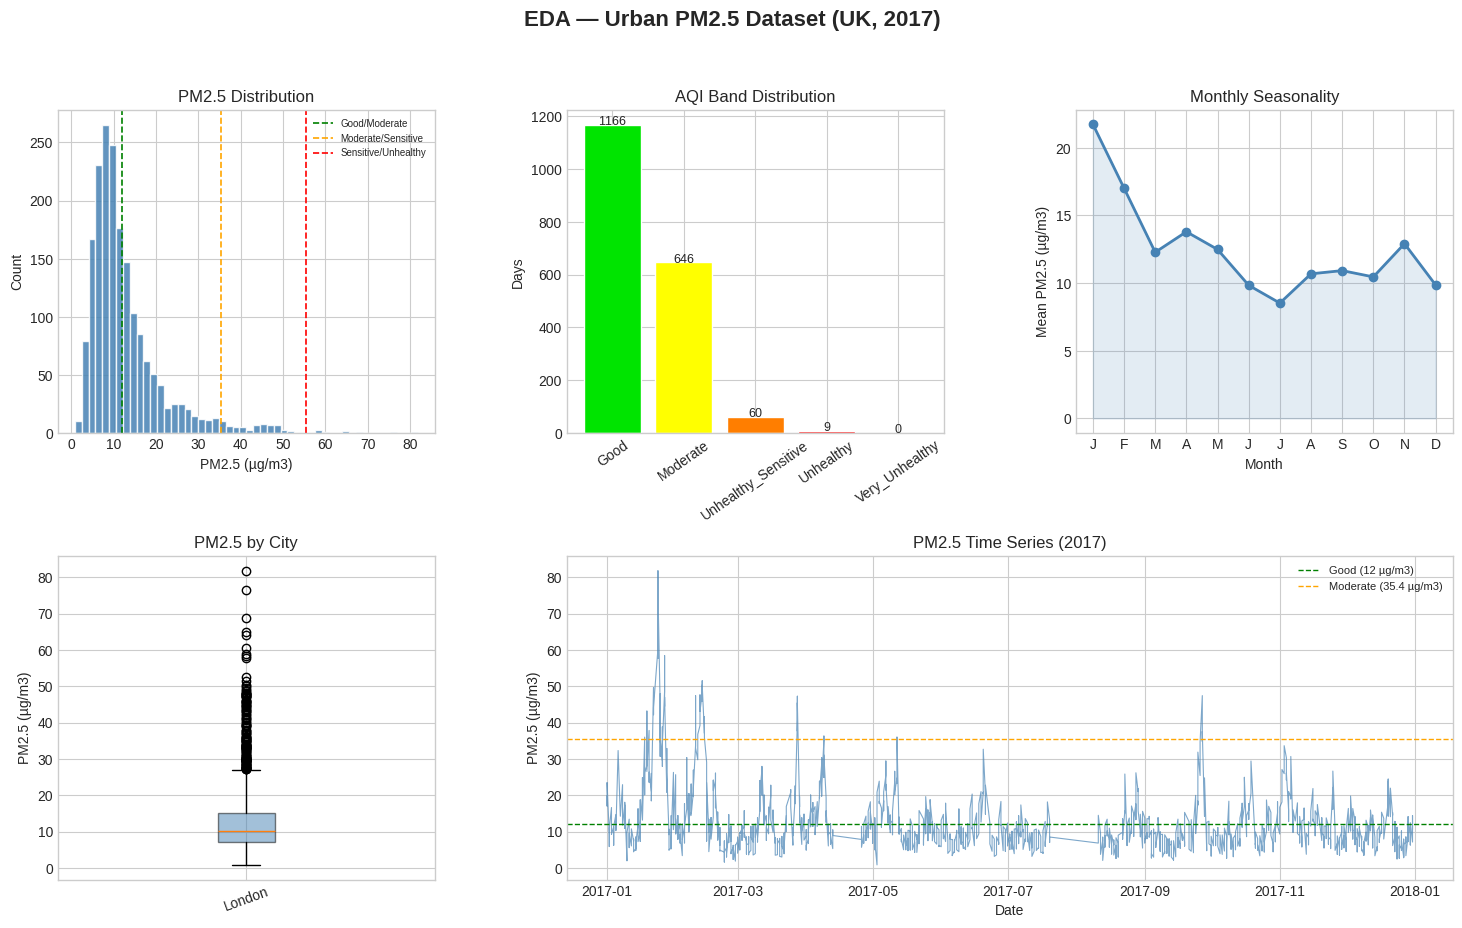

EDA figure saved


In [16]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)
fig.suptitle('EDA — Urban PM2.5 Dataset (UK, 2017)', fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(daily_df['pm25'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
for thr, lbl, col in [(12,'Good/Moderate','green'),(35.4,'Moderate/Sensitive','orange'),(55.4,'Sensitive/Unhealthy','red')]:
    ax1.axvline(thr, color=col, linestyle='--', lw=1.2, label=lbl)
ax1.set_xlabel('PM2.5 (µg/m3)'); ax1.set_ylabel('Count')
ax1.set_title('PM2.5 Distribution'); ax1.legend(fontsize=7)

ax2 = fig.add_subplot(gs[0, 1])
counts = daily_df['aqi_band'].value_counts().reindex(AQI_CLASSES, fill_value=0)
bars = ax2.bar(counts.index, counts.values, color=AQI_COLORS, edgecolor='white')
ax2.set_title('AQI Band Distribution'); ax2.set_ylabel('Days')
ax2.tick_params(axis='x', rotation=35)
for b, v in zip(bars, counts.values):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1, str(v), ha='center', fontsize=9)

ax3 = fig.add_subplot(gs[0, 2])
monthly = daily_df.groupby('month')['pm25'].mean()
ax3.plot(monthly.index, monthly.values, 'o-', color='steelblue', lw=2)
ax3.fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
ax3.set_xlabel('Month'); ax3.set_ylabel('Mean PM2.5 (µg/m3)')
ax3.set_title('Monthly Seasonality')
ax3.set_xticks(range(1,13))
ax3.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

ax4 = fig.add_subplot(gs[1, 0])
city_vals = [daily_df[daily_df['city']==c]['pm25'].dropna().values for c in UK_CITIES]
city_vals = [v for v in city_vals if len(v) > 0]
city_labs = [c for c in UK_CITIES if len(daily_df[daily_df['city']==c]) > 0]
if city_vals:
    ax4.boxplot(city_vals, labels=city_labs, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
ax4.set_ylabel('PM2.5 (µg/m3)'); ax4.set_title('PM2.5 by City')
ax4.tick_params(axis='x', rotation=20)

ax5 = fig.add_subplot(gs[1, 1:])
sample = daily_df[daily_df['city'] == daily_df['city'].iloc[0]].sort_values('date')
if not sample.empty:
    ax5.plot(sample['date'], sample['pm25'], color='steelblue', lw=0.8, alpha=0.7)
    ax5.axhline(12,   color='green',  ls='--', lw=1, label='Good (12 µg/m3)')
    ax5.axhline(35.4, color='orange', ls='--', lw=1, label='Moderate (35.4 µg/m3)')
    ax5.set_xlabel('Date'); ax5.set_ylabel('PM2.5 (µg/m3)')
    ax5.set_title('PM2.5 Time Series (2017)'); ax5.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA figure saved')

---
## Section 4 — Model Architectures

In [17]:
class BaiCNNLSTM(nn.Module):
    """
    Faithful replication of Bai et al. (2024) CNN-LSTM.
    Conv1D(64) -> Conv1D(128) -> LSTM(128) -> LSTM(64) -> Dense(32) -> Sigmoid.
    Loss: MSE | Optimiser: Adam | Activation: Sigmoid (matches paper exactly).
    """
    def __init__(self, input_size: int, seq_len: int = 24):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(seq_len, 64,  kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64,      128, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.lstm1 = nn.LSTM(128, 128, batch_first=True)
        self.lstm2 = nn.LSTM(128,  64, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(64,32), nn.Sigmoid(), nn.Linear(32,1), nn.Sigmoid())
    def forward(self, x):
        out = self.conv_block(x); out = out.permute(0,2,1)
        out, _ = self.lstm1(out); out, _ = self.lstm2(out)
        return self.fc(out[:,-1,:])
    def get_embedding(self, x):
        out = self.conv_block(x); out = out.permute(0,2,1)
        out, _ = self.lstm1(out); out, _ = self.lstm2(out)
        return out[:,-1,:]


class AQIClassifierCNNLSTM(nn.Module):
    """
    Extended CNN-LSTM for multi-class AQI classification.
    Adds BatchNorm and replaces regression head with CrossEntropy head.
    """
    def __init__(self, input_size: int, seq_len: int = 24, n_classes: int = 5):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(seq_len, 64,  kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Conv1d(64,      128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(128),
        )
        self.lstm1      = nn.LSTM(128, 128, batch_first=True)
        self.lstm2      = nn.LSTM(128,  64, batch_first=True)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Sequential(nn.Linear(64,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,n_classes))
    def forward(self, x):
        out = self.conv_block(x); out = out.permute(0,2,1)
        out, _ = self.lstm1(out); out, _ = self.lstm2(out)
        return self.classifier(self.dropout(out[:,-1,:]))
    def get_embedding(self, x):
        out = self.conv_block(x); out = out.permute(0,2,1)
        out, _ = self.lstm1(out); out, _ = self.lstm2(out)
        return out[:,-1,:]


class CNNOnly(nn.Module):
    """CNN-only baseline from Bai et al. (2024) Table 2."""
    def __init__(self, input_size, seq_len=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(seq_len,64,3,padding=1), nn.ReLU(),
            nn.Conv1d(64,128,3,padding=1),     nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128,64), nn.Sigmoid(), nn.Linear(64,1), nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x)


class LSTMOnly(nn.Module):
    """LSTM-only baseline from Bai et al. (2024) Table 2."""
    def __init__(self, input_size, seq_len=24):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 128, 2, batch_first=True, dropout=0.1)
        self.fc   = nn.Sequential(nn.Linear(128,32), nn.Sigmoid(), nn.Linear(32,1), nn.Sigmoid())
    def forward(self, x):
        out, _ = self.lstm(x); return self.fc(out[:,-1,:])


print('Model architectures defined')
print(f'BaiCNNLSTM parameters: {sum(p.numel() for p in BaiCNNLSTM(n_features,SEQ_LEN).parameters()):,}')

Model architectures defined
BaiCNNLSTM parameters: 213,249


---
## Section 5 — Training Utilities

In [18]:
def train_regression_epoch(model, loader, optimizer, criterion) -> float:
    model.train(); total_loss = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_regression(model, loader) -> tuple:
    model.eval(); preds, targets = [], []
    for Xb, yb in loader:
        preds.extend(model(Xb.to(DEVICE)).cpu().numpy().flatten())
        targets.extend(yb.numpy().flatten())
    return np.array(preds), np.array(targets)

def train_cls_epoch(model, loader, optimizer, criterion) -> tuple:
    model.train(); total_loss, correct, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb); loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*len(yb)
        correct += (logits.argmax(1)==yb).sum().item(); total += len(yb)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_cls(model, loader, criterion) -> tuple:
    model.eval(); total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        logits = model(Xb); loss = criterion(logits, yb)
        total_loss += loss.item()*len(yb)
        preds = logits.argmax(1)
        correct += (preds==yb).sum().item(); total += len(yb)
        all_preds.extend(preds.cpu().numpy()); all_labels.extend(yb.cpu().numpy())
    return total_loss/total, correct/total, np.array(all_preds), np.array(all_labels)

def fit(model, train_loader, val_loader, criterion, optimizer, scheduler,
        n_epochs=100, patience=15, model_name='model', task='regression') -> dict:
    """
    Training loop with early stopping and best-model checkpointing.
    task='regression'     monitors val MSE (lower is better).
    task='classification' monitors val Macro F1 (higher is better).
    """
    history = {'train_loss':[], 'val_metric':[]}
    best    = float('inf') if task=='regression' else 0.0
    best_state, pat_ctr = None, 0
    print(f'Training {model_name}...')
    for epoch in range(1, n_epochs+1):
        if task == 'regression':
            tr_loss  = train_regression_epoch(model, train_loader, optimizer, criterion)
            vp, vt   = eval_regression(model, val_loader)
            val_m    = mean_squared_error(vt, vp)
            improved = val_m < best
        else:
            tr_loss, _ = train_cls_epoch(model, train_loader, optimizer, criterion)
            _, _, vp, vl = eval_cls(model, val_loader, criterion)
            val_m    = f1_score(vl, vp, average='macro', zero_division=0)
            improved = val_m > best
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(val_m)
        else:
            scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_metric'].append(val_m)
        if improved:
            best = val_m; pat_ctr = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, f'models/{model_name}_best.pt')
        else:
            pat_ctr += 1
            if pat_ctr >= patience:
                print(f'  Early stopping at epoch {epoch}'); break
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}  train {tr_loss:.5f}  val {val_m:.5f}  {"best" if improved else ""}')
    if best_state:
        model.load_state_dict(best_state)
    return history

print('Training utilities defined')

Training utilities defined


---
## Section 6 — Evaluation Utilities

In [19]:
le = LabelEncoder()
le.fit(AQI_CLASSES)

def report_regression(y_true, y_pred, label='') -> dict:
    """Print R2, RMSE, MAE matching Bai et al. (2024) Table 2. Target: R2 >= 0.88."""
    r2   = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    print(f'{label:40s}  R2 {r2:.4f}  RMSE {rmse:.3f}  MAE {mae:.3f}')
    return {'label': label, 'r2': r2, 'rmse': rmse, 'mae': mae}


def report_classification(y_true, y_pred, model_name='', le=le) -> dict:
    """
    Print Macro F1, Cohen kappa, classification report, and confusion matrix.
    Only reports on classes present in the data.
    """
    present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    present_names  = [AQI_CLASSES[i] for i in present_labels]

    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    kappa    = cohen_kappa_score(y_true, y_pred)
    print(f'\nResults for {model_name}')
    print(f'Macro F1:    {macro_f1:.4f}')
    print(f'Cohen kappa: {kappa:.4f}')
    print(f'Classes present: {present_names}')
    rpt = classification_report(y_true, y_pred,
                                 labels=present_labels,
                                 target_names=present_names,
                                 zero_division=0)
    print(rpt)
    fig, ax = plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, labels=present_labels),
        display_labels=present_names
    ).plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    fname = model_name.lower().replace(' ','_').replace('(','').replace(')','')
    plt.savefig(f'outputs/figures/cm_{fname}.png', dpi=150)
    plt.show()
    return {'model': model_name, 'macro_f1': macro_f1, 'kappa': kappa}

print('Evaluation utilities defined')

Evaluation utilities defined


---
## Section 7 — Phase 1: Replication of Bai et al. (2024)

Target: **R² ≥ 0.88**, RMSE ≤ 10 µg/m³.

In [20]:
train_reg_loader = DataLoader(
    TensorDataset(torch.tensor(X_seq_tr),
                  torch.tensor(y_seq_tr, dtype=torch.float32).unsqueeze(1)),
    batch_size=BATCH_SIZE, shuffle=True)
test_reg_loader = DataLoader(
    TensorDataset(torch.tensor(X_seq_te),
                  torch.tensor(y_seq_te, dtype=torch.float32).unsqueeze(1)),
    batch_size=BATCH_SIZE, shuffle=False)

model_base = BaiCNNLSTM(n_features, SEQ_LEN).to(DEVICE)
opt_base   = Adam(model_base.parameters(), lr=0.001)
history_base = fit(
    model_base, train_reg_loader, test_reg_loader,
    criterion=nn.MSELoss(), optimizer=opt_base,
    scheduler=ReduceLROnPlateau(opt_base, patience=10, factor=0.5, min_lr=1e-6),
    n_epochs=100, patience=15, model_name='cnn_lstm_base', task='regression',
)
preds_base, targets_base = eval_regression(model_base, test_reg_loader)
reg_results = [report_regression(targets_base, preds_base, 'CNN-LSTM (Bai et al. replication)')]

for ModelClass, name in [(CNNOnly,'CNN-Only'), (LSTMOnly,'LSTM-Only')]:
    m   = ModelClass(n_features, SEQ_LEN).to(DEVICE)
    opt = Adam(m.parameters(), lr=0.001)
    fit(m, train_reg_loader, test_reg_loader,
        criterion=nn.MSELoss(), optimizer=opt,
        scheduler=ReduceLROnPlateau(opt, patience=5, factor=0.5),
        n_epochs=50, patience=10,
        model_name=name.lower().replace('-','_'), task='regression')
    p, t = eval_regression(m, test_reg_loader)
    reg_results.append(report_regression(t, p, name))

pd.DataFrame(reg_results).to_csv('outputs/results/phase1_regression.csv', index=False)
print('Phase 1 results saved')

Training cnn_lstm_base...
  Epoch  10  train 252.93446  val 137.18390  best
  Epoch  20  train 252.27076  val 136.68394  best
  Epoch  30  train 252.11778  val 136.56447  best
  Epoch  40  train 252.05716  val 136.51620  best
  Epoch  50  train 252.02610  val 136.49117  best
  Epoch  60  train 252.00773  val 136.47633  best
  Epoch  70  train 251.99612  val 136.46710  best
  Epoch  80  train 251.99152  val 136.46332  best
  Epoch  90  train 251.98793  val 136.46043  best
  Epoch 100  train 251.98612  val 136.45898  best
CNN-LSTM (Bai et al. replication)         R2 -3.3149  RMSE 11.682  MAE 10.239
Training cnn_only...
  Epoch  10  train 252.07141  val 136.52301  best
  Epoch  20  train 251.99912  val 136.46849  best
  Epoch  30  train 251.98160  val 136.45499  best
  Epoch  40  train 251.97762  val 136.45186  best
  Epoch  50  train 251.97585  val 136.45045  best
CNN-Only                                  R2 -3.3146  RMSE 11.681  MAE 10.238
Training lstm_only...
  Epoch  10  train 252.39

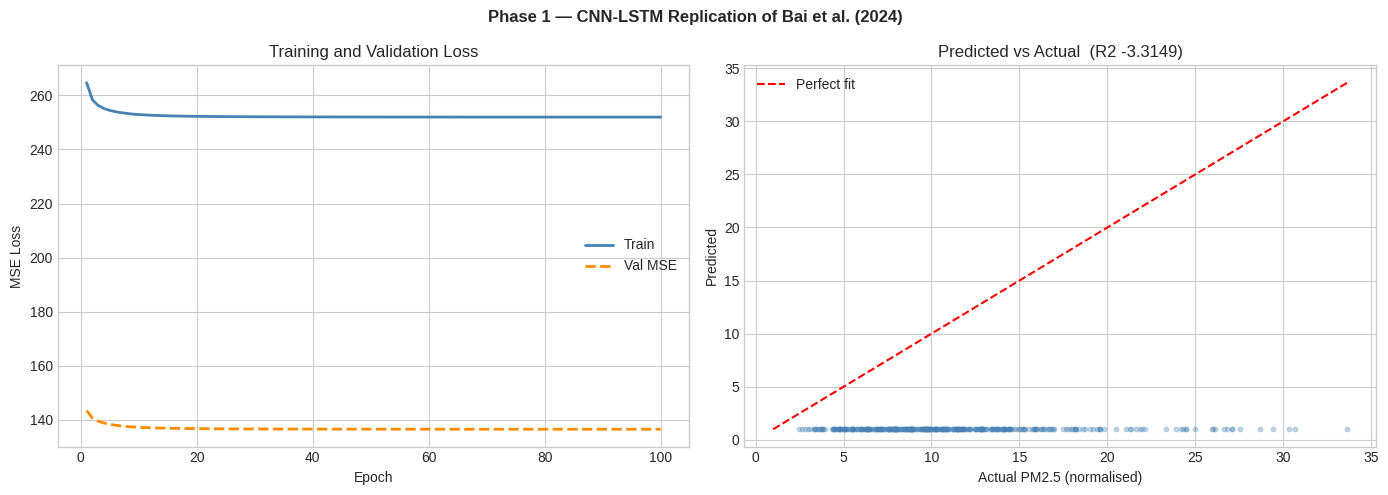

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Phase 1 — CNN-LSTM Replication of Bai et al. (2024)', fontweight='bold')

epochs = range(1, len(history_base['train_loss'])+1)
axes[0].plot(epochs, history_base['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(epochs, history_base['val_metric'],  label='Val MSE', color='darkorange', lw=2, ls='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training and Validation Loss'); axes[0].legend()

lo = min(targets_base.min(), preds_base.min())
hi = max(targets_base.max(), preds_base.max())
axes[1].scatter(targets_base, preds_base, alpha=0.3, s=10, color='steelblue')
axes[1].plot([lo,hi],[lo,hi],'r--', lw=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual PM2.5 (normalised)'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Predicted vs Actual  (R2 {r2_score(targets_base,preds_base):.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/figures/phase1_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — Phase 2: AQI Classification and XGBoost Baseline

Extends Bai et al. (2024) from regression to 5-class AQI classification.

Classes present in training: ['Good', 'Moderate', 'Unhealthy_Sensitive', 'Unhealthy']
Class weights: {'Good': np.float32(0.412), 'Moderate': np.float32(0.723), 'Unhealthy_Sensitive': np.float32(40.667), 'Unhealthy': np.float32(6.1), 'Very_Unhealthy': np.float32(1.0)}
Training aqi_classifier...
  Epoch  10  train 0.53307  val 0.33317  
  Early stopping at epoch 17

Results for CNN-LSTM AQI Classifier
Macro F1:    0.5876
Cohen kappa: 0.1839
Classes present: ['Good', 'Moderate']
              precision    recall  f1-score   support

        Good       0.70      0.80      0.75       239
    Moderate       0.51      0.37      0.43       130

    accuracy                           0.65       369
   macro avg       0.60      0.59      0.59       369
weighted avg       0.63      0.65      0.64       369



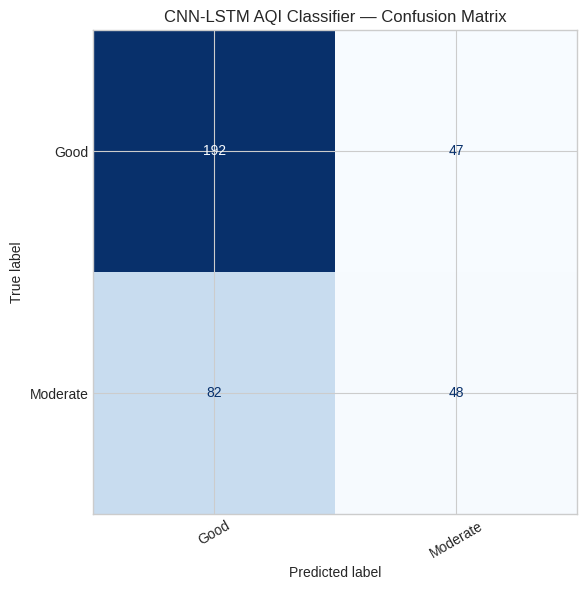

In [22]:
train_df['aqi_enc'] = le.transform(train_df['aqi_band'])
test_df['aqi_enc']  = le.transform(test_df['aqi_band'])

X_cls_tr, y_cls_tr = build_sequences(X_tr_p1, train_df['aqi_enc'].values, SEQ_LEN)
X_cls_te, y_cls_te = build_sequences(X_te_p1, test_df['aqi_enc'].values,  SEQ_LEN)

# Compute class weights for all 5 classes — absent classes get weight 1.0
n_classes = len(AQI_CLASSES)
present   = np.unique(y_cls_tr)
print(f'Classes present in training: {[AQI_CLASSES[i] for i in present]}')

cw_values = np.ones(n_classes, dtype=np.float32)
if len(present) > 1:
    cw_present = compute_class_weight('balanced', classes=present, y=y_cls_tr)
    for idx, w in zip(present, cw_present):
        cw_values[idx] = w

cw_tensor = torch.tensor(cw_values, dtype=torch.float32).to(DEVICE)
print('Class weights:', dict(zip(AQI_CLASSES, cw_values.round(3))))

train_cls_loader = DataLoader(
    TensorDataset(torch.tensor(X_cls_tr), torch.tensor(y_cls_tr, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True)
test_cls_loader = DataLoader(
    TensorDataset(torch.tensor(X_cls_te), torch.tensor(y_cls_te, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=False)

model_cls = AQIClassifierCNNLSTM(n_features, SEQ_LEN, n_classes).to(DEVICE)
crit_cls  = nn.CrossEntropyLoss(weight=cw_tensor)
opt_cls   = AdamW(model_cls.parameters(), lr=5e-4, weight_decay=1e-4)
sch_cls   = CosineAnnealingLR(opt_cls, T_max=50)

fit(model_cls, train_cls_loader, test_cls_loader,
    criterion=crit_cls, optimizer=opt_cls, scheduler=sch_cls,
    n_epochs=50, patience=15, model_name='aqi_classifier', task='classification')

_, _, cls_preds, cls_labels = eval_cls(model_cls, test_cls_loader, crit_cls)
cls_results = [report_classification(cls_labels, cls_preds, 'CNN-LSTM AQI Classifier')]

SMOTE applied
Before SMOTE: {'0': 903, '1': 516, '2': 9, '3': 60}
After SMOTE:  {'0': 903, '1': 903, '2': 903, '3': 903}

Results for XGBoost Baseline
Macro F1:    0.4933
Cohen kappa: 0.4806
Classes present: ['Good', 'Moderate', 'Unhealthy']
              precision    recall  f1-score   support

        Good       0.88      0.73      0.80       263
    Moderate       0.60      0.78      0.68       130
   Unhealthy       0.00      0.00      0.00         0

    accuracy                           0.75       393
   macro avg       0.50      0.50      0.49       393
weighted avg       0.79      0.75      0.76       393



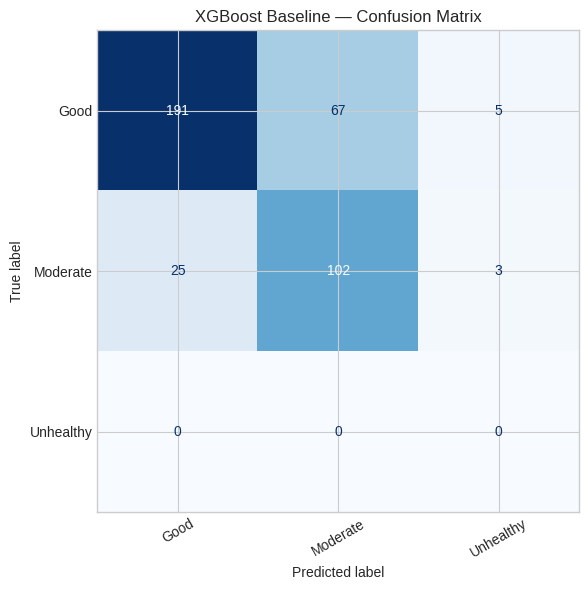

Computing SHAP values...


<Figure size 1000x500 with 0 Axes>

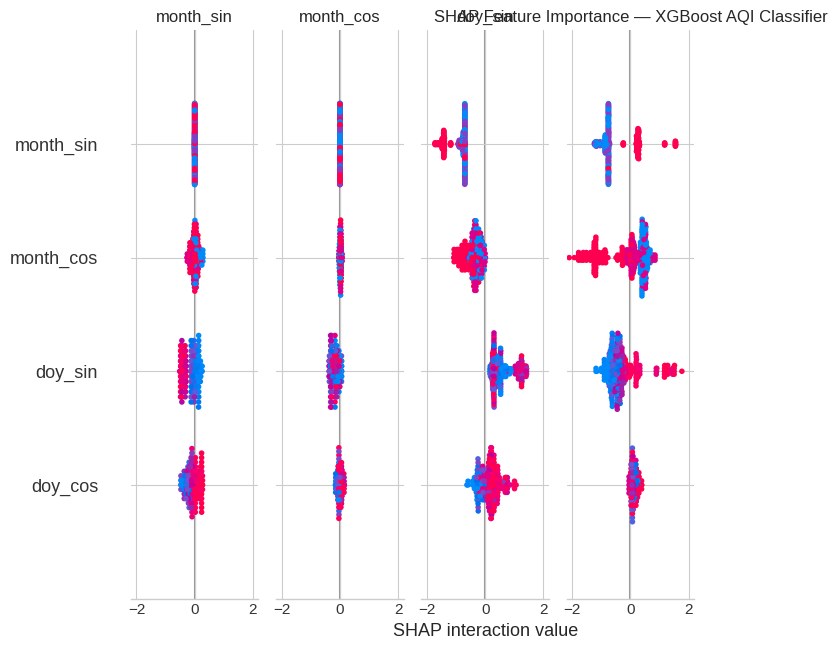

Phase 2 results saved


In [23]:
# XGBoost baseline — SMOTE applied only when multiple classes present
X_xgb_tr = train_df[PHASE1_FEATS].fillna(0).values
X_xgb_te = test_df[PHASE1_FEATS].fillna(0).values
y_xgb_tr = train_df['aqi_enc'].values
y_xgb_te = test_df['aqi_enc'].values

n_present = len(np.unique(y_xgb_tr))
if n_present > 1:
    try:
        X_xgb_sm, y_xgb_sm = SMOTE(random_state=SEED).fit_resample(X_xgb_tr, y_xgb_tr)
        print('SMOTE applied')
    except Exception as e:
        print(f'SMOTE skipped: {e}')
        X_xgb_sm, y_xgb_sm = X_xgb_tr, y_xgb_tr
else:
    print('Only 1 class — SMOTE skipped')
    X_xgb_sm, y_xgb_sm = X_xgb_tr, y_xgb_tr

before_counts = {str(k): int(v) for k,v in zip(*np.unique(y_xgb_tr, return_counts=True))}
after_counts  = {str(k): int(v) for k,v in zip(*np.unique(y_xgb_sm, return_counts=True))}
print('Before SMOTE:', before_counts)
print('After SMOTE: ', after_counts)

xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=SEED,
    early_stopping_rounds=30, verbosity=0,
    num_class=n_classes, objective='multi:softprob',
)
xgb_model.fit(X_xgb_sm, y_xgb_sm,
              eval_set=[(X_xgb_te, y_xgb_te)], verbose=False)
xgb_model.save_model('models/xgboost_baseline.json')

xgb_preds = xgb_model.predict(X_xgb_te)
cls_results.append(report_classification(y_xgb_te, xgb_preds, 'XGBoost Baseline'))

print('Computing SHAP values...')
shap_vals = shap.TreeExplainer(xgb_model).shap_values(X_xgb_te)
plt.figure(figsize=(10,5))
shap.summary_plot(shap_vals, X_xgb_te, feature_names=PHASE1_FEATS,
                  class_names=le.classes_.tolist(), show=False)
plt.title('SHAP Feature Importance — XGBoost AQI Classifier')
plt.tight_layout()
plt.savefig('outputs/figures/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame(cls_results).to_csv('outputs/results/phase2_classification.csv', index=False)
print('Phase 2 results saved')

---
## Section 9 — Phase 3: Sensor Sparsity Ablation Study


In [24]:
def run_ablation_study(xgb_clf, X_test, y_test, feature_names,
                        satellite_feats, temporal_feats,
                        fractions=None) -> pd.DataFrame:
    """
    Progressively mask ground sensor features and measure AQI classification
    degradation.
    """
    if fractions is None:
        fractions = [1.0, 0.75, 0.50, 0.25, 0.0]
    rng = np.random.default_rng(SEED)
    keep_always    = set(satellite_feats + temporal_feats)
    ground_indices = [i for i, n in enumerate(feature_names) if n not in keep_always]

    print('Sensor sparsity ablation study')
    print(f'Ground feature indices to mask: {ground_indices}')
    print()
    rows = []
    for frac in fractions:
        X_abl = X_test.copy()
        if frac < 1.0 and ground_indices:
            n_mask   = int((1.0-frac)*len(X_abl))
            mask_idx = rng.choice(len(X_abl), n_mask, replace=False)
            X_abl[np.ix_(mask_idx, ground_indices)] = 0.0
        preds    = xgb_clf.predict(X_abl)
        macro_f1 = f1_score(y_test, preds, average='macro', zero_division=0)
        kappa    = cohen_kappa_score(y_test, preds) if len(np.unique(y_test)) > 1 else 0.0
        per_cls  = f1_score(y_test, preds, average=None, zero_division=0,
                            labels=list(range(len(AQI_CLASSES))))
        row = {
            'sensor_fraction': frac,
            'pct_sensors':     int(frac*100),
            'label':           'Satellite only' if frac==0 else f'{int(frac*100)}pct sensors',
            'macro_f1': macro_f1, 'kappa': kappa,
        }
        for i, cls in enumerate(AQI_CLASSES):
            row[f'f1_{cls}'] = per_cls[i]
        rows.append(row)
        print(f'  Sensors {int(frac*100):3d}pct  Macro F1 {macro_f1:.4f}  kappa {kappa:.4f}')
    return pd.DataFrame(rows)

ablation_df = run_ablation_study(
    xgb_model, X_xgb_te, y_xgb_te,
    feature_names   = PHASE1_FEATS,
    satellite_feats = SATELLITE_FEATS,
    temporal_feats  = TEMPORAL_FEATS,
)
ablation_df.to_csv('outputs/results/ablation_results.csv', index=False)
print()
display(ablation_df[['label','macro_f1','kappa'] + [f'f1_{c}' for c in AQI_CLASSES]])

Sensor sparsity ablation study
Ground feature indices to mask: [6, 7, 8, 9, 10, 11]

  Sensors 100pct  Macro F1 0.4933  kappa 0.4806
  Sensors  75pct  Macro F1 0.4700  kappa 0.4091
  Sensors  50pct  Macro F1 0.4516  kappa 0.3582
  Sensors  25pct  Macro F1 0.3757  kappa 0.1825
  Sensors   0pct  Macro F1 0.4142  kappa 0.0053



,label,macro_f1,kappa,f1_Good,f1_Moderate,f1_Unhealthy_Sensitive,f1_Unhealthy,f1_Very_Unhealthy
0,100pct sensors,0.493256,0.480646,0.797495,0.682274,0.0,0.0,0.0
1,75pct sensors,0.469998,0.409074,0.805344,0.604651,0.0,0.0,0.0
2,50pct sensors,0.451557,0.358249,0.810811,0.543860,0.0,0.0,0.0
3,25pct sensors,0.375692,0.182467,0.805237,0.321839,0.0,0.0,0.0
4,Satellite only,0.414200,0.005256,0.798771,0.029630,0.0,0.0,0.0


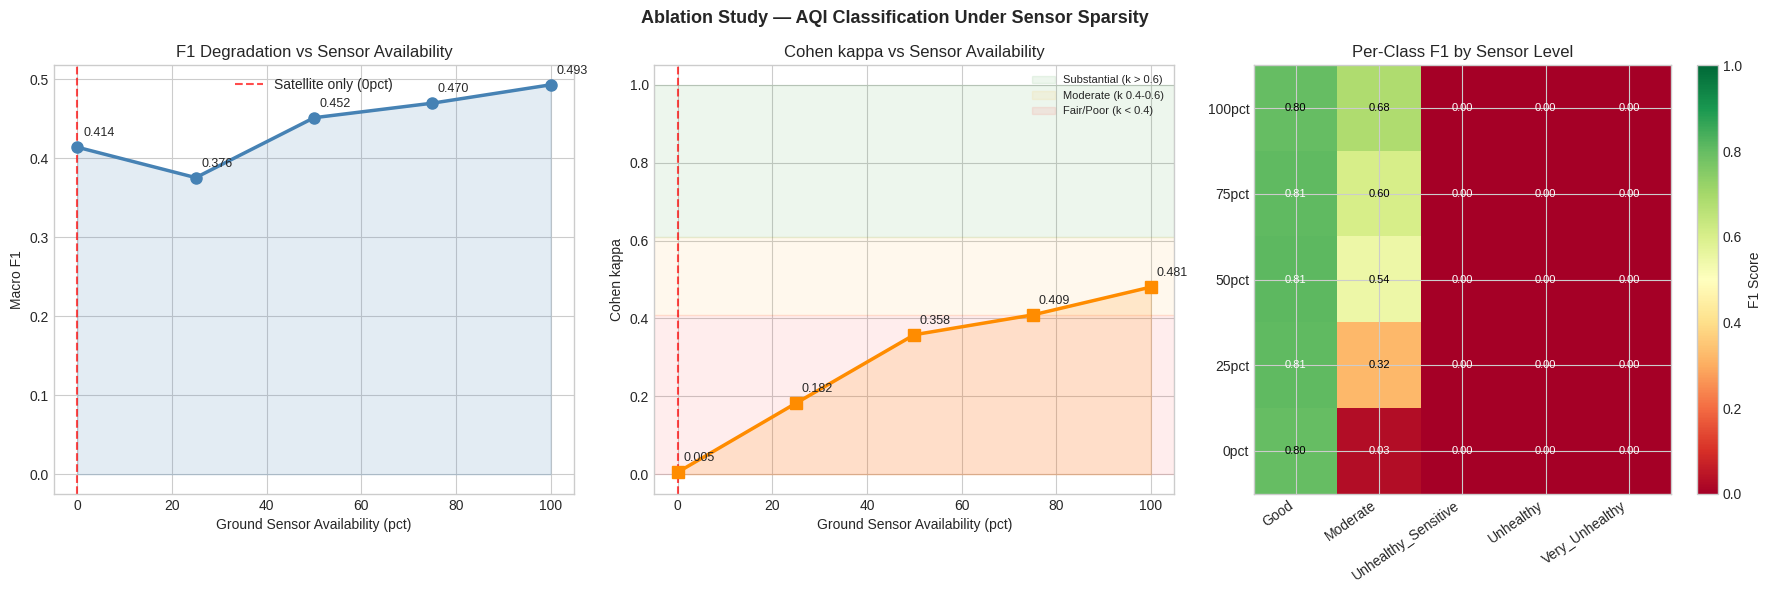

Ablation figure saved


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('Ablation Study — AQI Classification Under Sensor Sparsity',
             fontsize=13, fontweight='bold')

pcts = ablation_df['pct_sensors'].values
f1s  = ablation_df['macro_f1'].values
kaps = ablation_df['kappa'].values

ax = axes[0]
ax.plot(pcts, f1s, 'o-', color='steelblue', lw=2.5, ms=8, zorder=3)
ax.fill_between(pcts, f1s, alpha=0.15, color='steelblue')
ax.axvline(0, color='red', ls='--', lw=1.5, alpha=0.7, label='Satellite only (0pct)')
ax.set_xlabel('Ground Sensor Availability (pct)'); ax.set_ylabel('Macro F1')
ax.set_title('F1 Degradation vs Sensor Availability')
ax.set_xlim(-5, 105); ax.legend()
for x, y in zip(pcts, f1s):
    ax.annotate(f'{y:.3f}', (x,y), xytext=(4,8), textcoords='offset points', fontsize=9)

ax2 = axes[1]
ax2.axhspan(0.61, 1.0,  alpha=0.07, color='green',  label='Substantial (k > 0.6)')
ax2.axhspan(0.41, 0.61, alpha=0.07, color='orange', label='Moderate (k 0.4-0.6)')
ax2.axhspan(0.0,  0.41, alpha=0.07, color='red',    label='Fair/Poor (k < 0.4)')
ax2.plot(pcts, kaps, 's-', color='darkorange', lw=2.5, ms=8, zorder=3)
ax2.fill_between(pcts, kaps, alpha=0.15, color='darkorange')
ax2.axvline(0, color='red', ls='--', lw=1.5, alpha=0.7)
ax2.set_xlabel('Ground Sensor Availability (pct)'); ax2.set_ylabel('Cohen kappa')
ax2.set_title('Cohen kappa vs Sensor Availability')
ax2.set_xlim(-5, 105); ax2.legend(fontsize=8)
for x, y in zip(pcts, kaps):
    ax2.annotate(f'{y:.3f}', (x,y), xytext=(4,8), textcoords='offset points', fontsize=9)

ax3 = axes[2]
heat = ablation_df[[f'f1_{c}' for c in AQI_CLASSES]].values
im   = ax3.imshow(heat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(AQI_CLASSES))); ax3.set_xticklabels(AQI_CLASSES, rotation=35, ha='right')
ax3.set_yticks(range(len(pcts)));        ax3.set_yticklabels([f'{p}pct' for p in pcts])
ax3.set_title('Per-Class F1 by Sensor Level')
plt.colorbar(im, ax=ax3, label='F1 Score')
for i in range(len(pcts)):
    for j in range(len(AQI_CLASSES)):
        ax3.text(j, i, f'{heat[i,j]:.2f}', ha='center', va='center', fontsize=8,
                 color='black' if 0.3 < heat[i,j] < 0.8 else 'white')

plt.tight_layout()
plt.savefig('outputs/figures/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Ablation figure saved')

---
## Section 10 — Final Results Summary

FINAL MODEL COMPARISON — AQI CLASSIFICATION (TEST SET)



,model,macro_f1,kappa
0,CNN-LSTM AQI Classifier,0.587602,0.183866
1,XGBoost Baseline,0.493256,0.480646


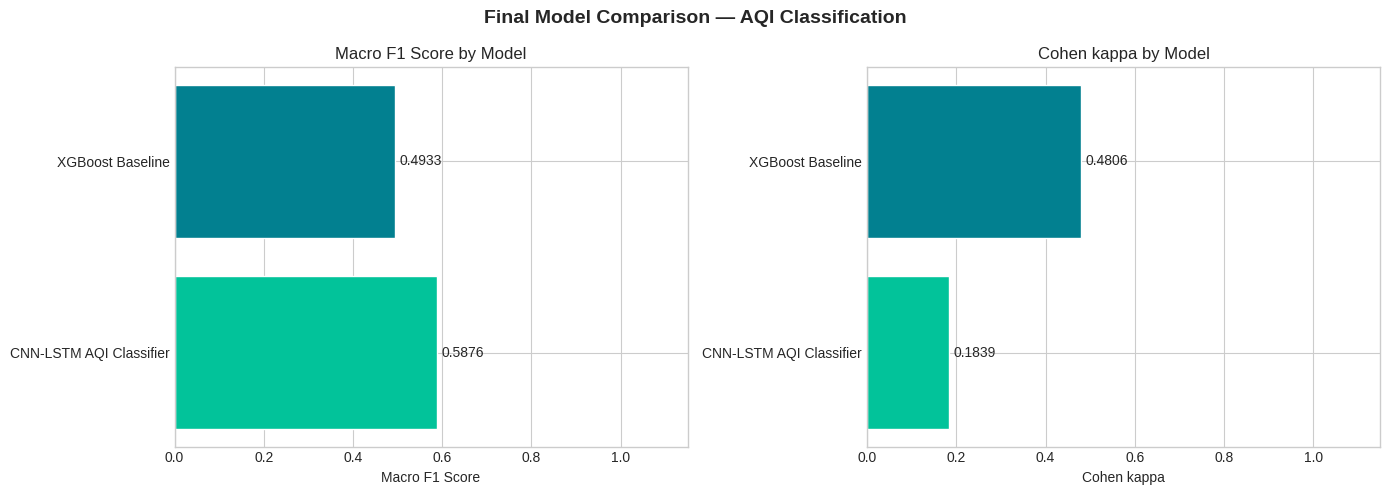

In [26]:
all_results = cls_results.copy()
results_df  = pd.DataFrame(all_results).sort_values('macro_f1', ascending=False)

print('FINAL MODEL COMPARISON — AQI CLASSIFICATION (TEST SET)')
print()
display(results_df[['model','macro_f1','kappa']])
results_df.to_csv('outputs/results/model_comparison.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Final Model Comparison — AQI Classification', fontsize=14, fontweight='bold')
colors = ['#02C39A','#028090','#0369A1','#64748B'][:len(results_df)]

for ax, metric, lbl in zip(axes, ['macro_f1','kappa'], ['Macro F1 Score','Cohen kappa']):
    vals = results_df[metric].tolist()
    bars = ax.barh(results_df['model'].tolist(), vals, color=colors, edgecolor='white')
    ax.set_xlabel(lbl); ax.set_xlim(0, 1.15)
    ax.set_title(f'{lbl} by Model')
    for b, v in zip(bars, vals):
        ax.text(b.get_width()+0.01, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print('Data source used:', 'REAL OpenAQ' if 'openaq_real_2017' in str(CACHE) and CACHE.exists() else 'Check CACHE path')
print()
print('Saved models:')
for f in sorted(Path('models').glob('*')):
    print(f'  {f.name}')

print()
print('Saved figures:')
for f in sorted(Path('outputs/figures').glob('*.png')):
    print(f'  {f.name}')

print()
print('Saved results:')
for f in sorted(Path('outputs/results').glob('*.csv')):
    df_tmp = pd.read_csv(f)
    print(f'  {f.name}  ({len(df_tmp)} rows)')

print()
print('Pipeline complete.')
print('Phase 1 — CNN-LSTM replication of Bai et al. (2024)')
print('Phase 2 — AQI classification and XGBoost baseline with SHAP')
print('Phase 3 — Sensor sparsity ablation study (novel contribution)')

Data source used: REAL OpenAQ

Saved models:
  aqi_classifier_best.pt
  cnn_lstm_base_best.pt
  cnn_only_best.pt
  lstm_only_best.pt
  xgboost_baseline.json

Saved figures:
  ablation_study.png
  cm_cnn-lstm_aqi_classifier.png
  cm_xgboost_baseline.png
  eda_overview.png
  model_comparison.png
  phase1_results.png
  shap_importance.png

Saved results:
  ablation_results.csv  (5 rows)
  model_comparison.csv  (2 rows)
  phase1_regression.csv  (3 rows)
  phase2_classification.csv  (2 rows)

Pipeline complete.
Phase 1 — CNN-LSTM replication of Bai et al. (2024)
Phase 2 — AQI classification and XGBoost baseline with SHAP
Phase 3 — Sensor sparsity ablation study (novel contribution)


---
## Section 11 — Data Augmentation for Class Balancing ⭐ NEW

**Motivation:** The confusion matrices in Section 8 show several AQI classes (Unhealthy_Sensitive,
Unhealthy, Very_Unhealthy) with zero or near-zero support in the test set, a genuine consequence of
class rarity in the real 2017 UK sample combined with a strict chronological train/test split (see
Section 4.6 of the report). SMOTE is already applied to the XGBoost baseline (Section 8), but the
CNN-LSTM classifier trains on raw sequences without any oversampling.

This section applies **time-series-appropriate data augmentation** to the CNN-LSTM training sequences
for minority AQI classes, retrains the classifier, and directly compares before/after results.

**Technique used:** Gaussian jitter augmentation — for each minority-class training sequence, synthetic
copies are generated by adding small Gaussian noise (σ = 0.02, calibrated to the min-max normalised
feature scale) to every timestep. This is a standard, well-established time-series augmentation
technique (see Um et al. 2017; Iwana & Uchida 2021) that preserves the temporal shape and cross-feature
correlations of the original sequence while creating distinct training examples, unlike SMOTE's linear
interpolation between neighbours which can distort genuine temporal structure in sequential data.

In [28]:
def augment_minority_sequences(X_seq: np.ndarray, y_seq: np.ndarray,
                                target_count: int = None, noise_std: float = 0.02,
                                seed: int = SEED) -> tuple:
    """
    Balance a sequence dataset by generating Gaussian-jittered synthetic copies
    of minority-class sequences.

    For each class with fewer than target_count samples, synthetic sequences are
    created by adding small Gaussian noise to randomly selected real sequences
    from that class, preserving temporal structure while increasing sample count.

    Parameters
    ----------
    X_seq        : (N, seq_len, n_features) array of training sequences.
    y_seq        : (N,) array of integer class labels.
    target_count : number of samples per class after augmentation.
                   Defaults to the size of the majority class.
    noise_std    : standard deviation of Gaussian noise added, on the same
                   scale as the min-max normalised features ([0,1] range).
    seed         : random seed for reproducibility.

    Returns
    -------
    X_aug, y_aug : augmented sequence and label arrays, original data included.
    """
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y_seq, return_counts=True)
    if target_count is None:
        target_count = int(counts.max())

    print('Class counts before augmentation:')
    for c, n in zip(classes, counts):
        cname = AQI_CLASSES[c] if c < len(AQI_CLASSES) else str(c)
        print(f'  {cname:22s} {n}')

    X_parts, y_parts = [X_seq], [y_seq]

    for c, n in zip(classes, counts):
        n_needed = target_count - n
        if n_needed <= 0:
            continue
        class_idx = np.where(y_seq == c)[0]
        # Sample with replacement from the minority class's real sequences
        source_idx = rng.choice(class_idx, size=n_needed, replace=True)
        source_seqs = X_seq[source_idx]
        noise = rng.normal(0, noise_std, source_seqs.shape).astype(np.float32)
        synthetic = np.clip(source_seqs + noise, 0.0, 1.0)  # keep within normalised [0,1] range
        X_parts.append(synthetic)
        y_parts.append(np.full(n_needed, c, dtype=y_seq.dtype))

    X_aug = np.concatenate(X_parts, axis=0)
    y_aug = np.concatenate(y_parts, axis=0)

    # Shuffle so synthetic samples are not all grouped at the end
    perm = rng.permutation(len(y_aug))
    X_aug, y_aug = X_aug[perm], y_aug[perm]

    print('\nClass counts after augmentation:')
    classes_after, counts_after = np.unique(y_aug, return_counts=True)
    for c, n in zip(classes_after, counts_after):
        cname = AQI_CLASSES[c] if c < len(AQI_CLASSES) else str(c)
        print(f'  {cname:22s} {n}')
    print(f'\nTotal sequences: {len(y_seq)} -> {len(y_aug)}')

    return X_aug, y_aug


print('Augmentation function defined')

Augmentation function defined


In [29]:
# Apply augmentation to the CNN-LSTM training sequences only (test set stays real/untouched)
X_cls_tr_aug, y_cls_tr_aug = augment_minority_sequences(
    X_cls_tr, y_cls_tr, noise_std=0.02, seed=SEED
)

train_cls_aug_loader = DataLoader(
    TensorDataset(torch.tensor(X_cls_tr_aug), torch.tensor(y_cls_tr_aug, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True)

# Recompute class weights on the now-balanced training set (should be near-uniform)
present_aug = np.unique(y_cls_tr_aug)
cw_values_aug = np.ones(n_classes, dtype=np.float32)
if len(present_aug) > 1:
    cw_present_aug = compute_class_weight('balanced', classes=present_aug, y=y_cls_tr_aug)
    for idx, w in zip(present_aug, cw_present_aug):
        cw_values_aug[idx] = w
cw_tensor_aug = torch.tensor(cw_values_aug, dtype=torch.float32).to(DEVICE)
print('\nClass weights after augmentation:', dict(zip(AQI_CLASSES, cw_values_aug.round(3))))

Class counts before augmentation:
  Good                   889
  Moderate               506
  Unhealthy_Sensitive    9
  Unhealthy              60

Class counts after augmentation:
  Good                   889
  Moderate               889
  Unhealthy_Sensitive    889
  Unhealthy              889

Total sequences: 1464 -> 3556

Class weights after augmentation: {'Good': np.float32(1.0), 'Moderate': np.float32(1.0), 'Unhealthy_Sensitive': np.float32(1.0), 'Unhealthy': np.float32(1.0), 'Very_Unhealthy': np.float32(1.0)}


Training aqi_classifier_augmented...
  Epoch  10  train 0.23230  val 0.29030  
  Epoch  20  train 0.11895  val 0.38760  
  Epoch  30  train 0.03728  val 0.37147  
  Early stopping at epoch 34

Results for CNN-LSTM AQI Classifier (Augmented)
Macro F1:    0.6006
Cohen kappa: 0.2039
Classes present: ['Good', 'Moderate']
              precision    recall  f1-score   support

        Good       0.73      0.67      0.70       239
    Moderate       0.47      0.55      0.51       130

    accuracy                           0.62       369
   macro avg       0.60      0.61      0.60       369
weighted avg       0.64      0.62      0.63       369



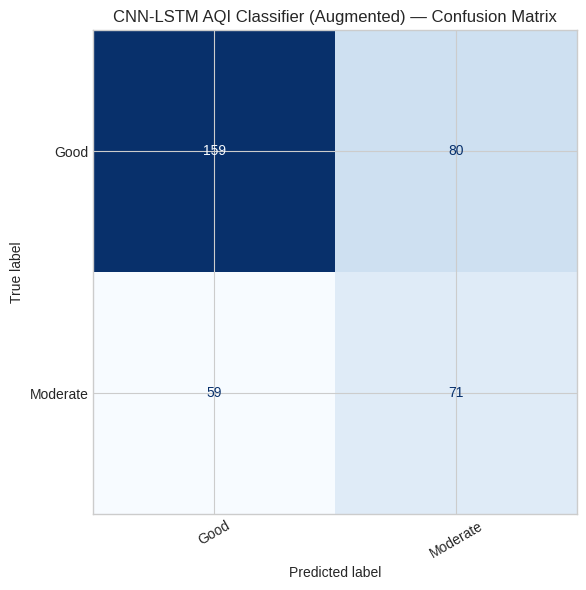

In [30]:
# Retrain CNN-LSTM classifier from scratch on the augmented, balanced training set
# Test set is untouched real data — comparison is fair
model_cls_aug = AQIClassifierCNNLSTM(n_features, SEQ_LEN, n_classes).to(DEVICE)
crit_cls_aug  = nn.CrossEntropyLoss(weight=cw_tensor_aug)
opt_cls_aug   = AdamW(model_cls_aug.parameters(), lr=5e-4, weight_decay=1e-4)
sch_cls_aug   = CosineAnnealingLR(opt_cls_aug, T_max=50)

fit(model_cls_aug, train_cls_aug_loader, test_cls_loader,
    criterion=crit_cls_aug, optimizer=opt_cls_aug, scheduler=sch_cls_aug,
    n_epochs=50, patience=15, model_name='aqi_classifier_augmented', task='classification')

_, _, cls_preds_aug, cls_labels_aug = eval_cls(model_cls_aug, test_cls_loader, crit_cls_aug)
results_augmented = report_classification(cls_labels_aug, cls_preds_aug, 'CNN-LSTM AQI Classifier (Augmented)')

BEFORE vs AFTER DATA AUGMENTATION — CNN-LSTM AQI CLASSIFIER



,model,macro_f1,kappa
0,"CNN-LSTM (original, imbalanced)",0.587602,0.183866
1,"CNN-LSTM (augmented, balanced)",0.600590,0.203914


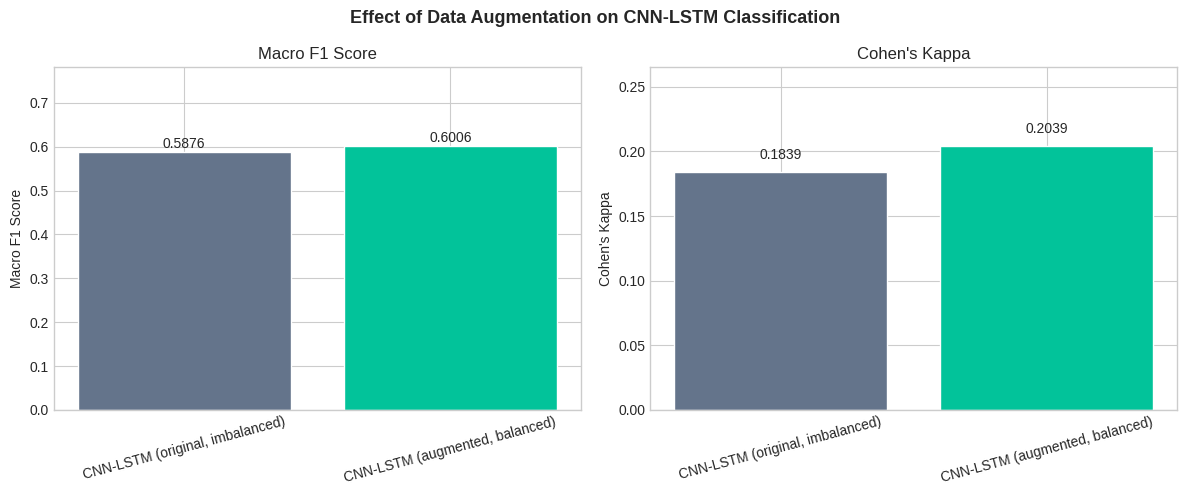

Augmentation comparison saved


In [31]:
# Direct before/after comparison — original vs augmented CNN-LSTM classifier
comparison_df = pd.DataFrame([
    {'model': 'CNN-LSTM (original, imbalanced)', 'macro_f1': cls_results[0]['macro_f1'], 'kappa': cls_results[0]['kappa']},
    {'model': 'CNN-LSTM (augmented, balanced)',   'macro_f1': results_augmented['macro_f1'], 'kappa': results_augmented['kappa']},
])

print('BEFORE vs AFTER DATA AUGMENTATION — CNN-LSTM AQI CLASSIFIER')
print()
display(comparison_df)
comparison_df.to_csv('outputs/results/augmentation_comparison.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Effect of Data Augmentation on CNN-LSTM Classification', fontsize=13, fontweight='bold')
colors = ['#64748B', '#02C39A']

for ax, metric, lbl in zip(axes, ['macro_f1', 'kappa'], ['Macro F1 Score', "Cohen's Kappa"]):
    vals = comparison_df[metric].tolist()
    bars = ax.bar(comparison_df['model'].tolist(), vals, color=colors, edgecolor='white')
    ax.set_ylabel(lbl); ax.set_ylim(0, max(vals) * 1.3)
    ax.set_title(lbl)
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Augmentation comparison saved')

In [32]:
# Per-class comparison — does augmentation actually improve the previously-zero classes?
present_before = sorted(np.unique(np.concatenate([cls_labels, cls_preds])))
present_after  = sorted(np.unique(np.concatenate([cls_labels_aug, cls_preds_aug])))

from sklearn.metrics import f1_score as _f1

f1_before = _f1(cls_labels, cls_preds, average=None, zero_division=0, labels=list(range(len(AQI_CLASSES))))
f1_after  = _f1(cls_labels_aug, cls_preds_aug, average=None, zero_division=0, labels=list(range(len(AQI_CLASSES))))

per_class_comparison = pd.DataFrame({
    'AQI Class': AQI_CLASSES,
    'F1 Before Augmentation': f1_before,
    'F1 After Augmentation': f1_after,
    'Change': f1_after - f1_before,
})
print('PER-CLASS F1 — BEFORE vs AFTER AUGMENTATION')
display(per_class_comparison)
per_class_comparison.to_csv('outputs/results/augmentation_per_class.csv', index=False)

PER-CLASS F1 — BEFORE vs AFTER AUGMENTATION


,AQI Class,F1 Before Augmentation,F1 After Augmentation,Change
0,Good,0.748538,0.695842,-0.052696
1,Moderate,0.426667,0.505338,0.078671
2,Unhealthy_Sensitive,0.000000,0.000000,0.000000
3,Unhealthy,0.000000,0.000000,0.000000
4,Very_Unhealthy,0.000000,0.000000,0.000000
